# 04 — Error Analysis: Чому ми пропускаємо 4.9% шахраїв?

Аналіз упущених шахраїв (`missed_fraud`) порівняно зі спійманими (`caught_fraud`).
Мета: знайти слабкі місця поточної моделі та сформувати гіпотези для нових ознак (фіч).

**Етапи:**
1. Завантаження моделі та генерація прогнозів на тренувальному наборі даних
2. Порівняння розподілів фіч (Упущені vs Спіймані)
3. Профілювання упущених шахраїв
4. Пошук прихованих патернів (гіпотези)
5. Висновки: нові кандидати у фічі

In [1]:
FEATURE_COLS = [
    'is_instant_registration', 'has_night_tx', 'is_country_mismatch',
    'is_pay_mismatch', 'total_transactions', 'total_unique_cards',
    'success_rate', 'failed_tx_count', 'has_fraud_error',
    'has_name_email_match', 'traffic_type_enc', 'cards_per_tx',
    'single_attempt', 'days_active', 'n_error_types',
    'n_card_brands', 'n_tx_types',
    'tx_24h', 'tx_7d', 'hours_to_first_tx_log',
    'first_tx_failed', 'first_tx_fraud_error',
    'fraud_error_rate', 'country_mismatch_rate',
    'shared_card_users_max', 'reg_country_risk_oof', 'gender_risk_oof'
]
TARGET = 'is_fraud'


## Крок 1 — Завантаження моделі та генерація прогнозів на повному тренувальному наборі

In [2]:
print("Завантаження даних...")
train_df = pd.read_csv('../data/processed/train_features.csv')

# Перенавчаємо фінальну модель v3 безпосередньо тут для консистентності
best_params = {
    'learning_rate': 0.008916692091985538,
    'n_estimators': 2596,
    'num_leaves': 87,
    'max_depth': 9,
    'min_child_samples': 34,
    'reg_alpha': 0.43533589861663646,
    'reg_lambda': 2.6908735954345224e-06,
    'subsample': 0.9561440040544894,
    'colsample_bytree': 0.9962408446938177,
    'scale_pos_weight': 16.62357688635674,
    'random_state': 42,
    'verbose': -1
}

X = train_df[FEATURE_COLS]
y = train_df[TARGET]

print("Навчання моделі...")
final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(X, y)

print("Генерація прогнозів...")
train_df['fraud_proba'] = final_model.predict_proba(X)[:, 1]
train_df['predicted'] = (train_df['fraud_proba'] >= BEST_THRESHOLD).astype(int)

# Відфільтровуємо лише дійсних шахраїв
actual_fraud = train_df[train_df['is_fraud'] == 1].copy()

# Розділяємо на упущених(missed) і спійманих(caught)
actual_fraud['status'] = np.where(actual_fraud['predicted'] == 1, 'спійманий_шахрай', 'упущений_шахрай')
missed_fraud = actual_fraud[actual_fraud['status'] == 'упущений_шахрай']
caught_fraud = actual_fraud[actual_fraud['status'] == 'спійманий_шахрай']

print(f"\nУсього дійсних шахраїв: {len(actual_fraud)}")
print(f"✅ Спіймані шахраї: {len(caught_fraud)} ({len(caught_fraud)/len(actual_fraud)*100:.1f}%)")
print(f"❌ Упущені шахраї: {len(missed_fraud)} ({len(missed_fraud)/len(actual_fraud)*100:.1f}%)")

Завантаження даних...
Навчання моделі...


Генерація прогнозів...



Усього дійсних шахраїв: 14932
✅ Спіймані шахраї: 14197 (95.1%)
❌ Упущені шахраї: 735 (4.9%)


## Крок 2 — Порівняння розподілів фіч (Упущені vs Спіймані)

In [3]:
# Порівняння середніх значень
compare_df = pd.DataFrame({
    'Середнє (Упущені)': missed_fraud[FEATURE_COLS].mean(),
    'Середнє (Спіймані)': caught_fraud[FEATURE_COLS].mean()
})

# Обчислення відносної різниці (Упущені / Спіймані)
compare_df['Відношення (Упущені/Спіймані)'] = compare_df['Середнє (Упущені)'] / compare_df['Середнє (Спіймані)']
compare_df['Різниця'] = compare_df['Середнє (Упущені)'] - compare_df['Середнє (Спіймані)']

# Сортуємо за абсолютним відношенням, щоб побачити найбільші поведінкові розриви
compare_df = compare_df.sort_values(by='Відношення (Упущені/Спіймані)', ascending=False)

print("Середні значення фіч: Упущені шахраї vs Спіймані шахраї")
pd.set_option('display.float_format', lambda x: '%.4f' % x)
display(compare_df)

Середні значення фіч: Упущені шахраї vs Спіймані шахраї


,Середнє (Упущені),Середнє (Спіймані),Відношення (Упущені/Спіймані),Різниця
cards_per_tx,0.7197,0.5379,1.3380,0.1818
has_name_email_match,0.3673,0.3132,1.1730,0.0542
success_rate,0.1845,0.2035,0.9065,-0.0190
has_night_tx,0.3333,0.5218,0.6388,-0.1885
traffic_type_enc,0.0339,0.0592,0.5734,-0.0252
total_unique_cards,1.0680,3.9227,0.2723,-2.8546
has_fraud_error,0.0993,0.4140,0.2399,-0.3147
failed_tx_count,1.4313,18.2424,0.0785,-16.8111
is_pay_mismatch,0.0082,0.1378,0.0593,-0.1296
total_transactions,2.0585,36.6897,0.0561,-34.6311


## Крок 3 — Профілювання упущених шахраїв

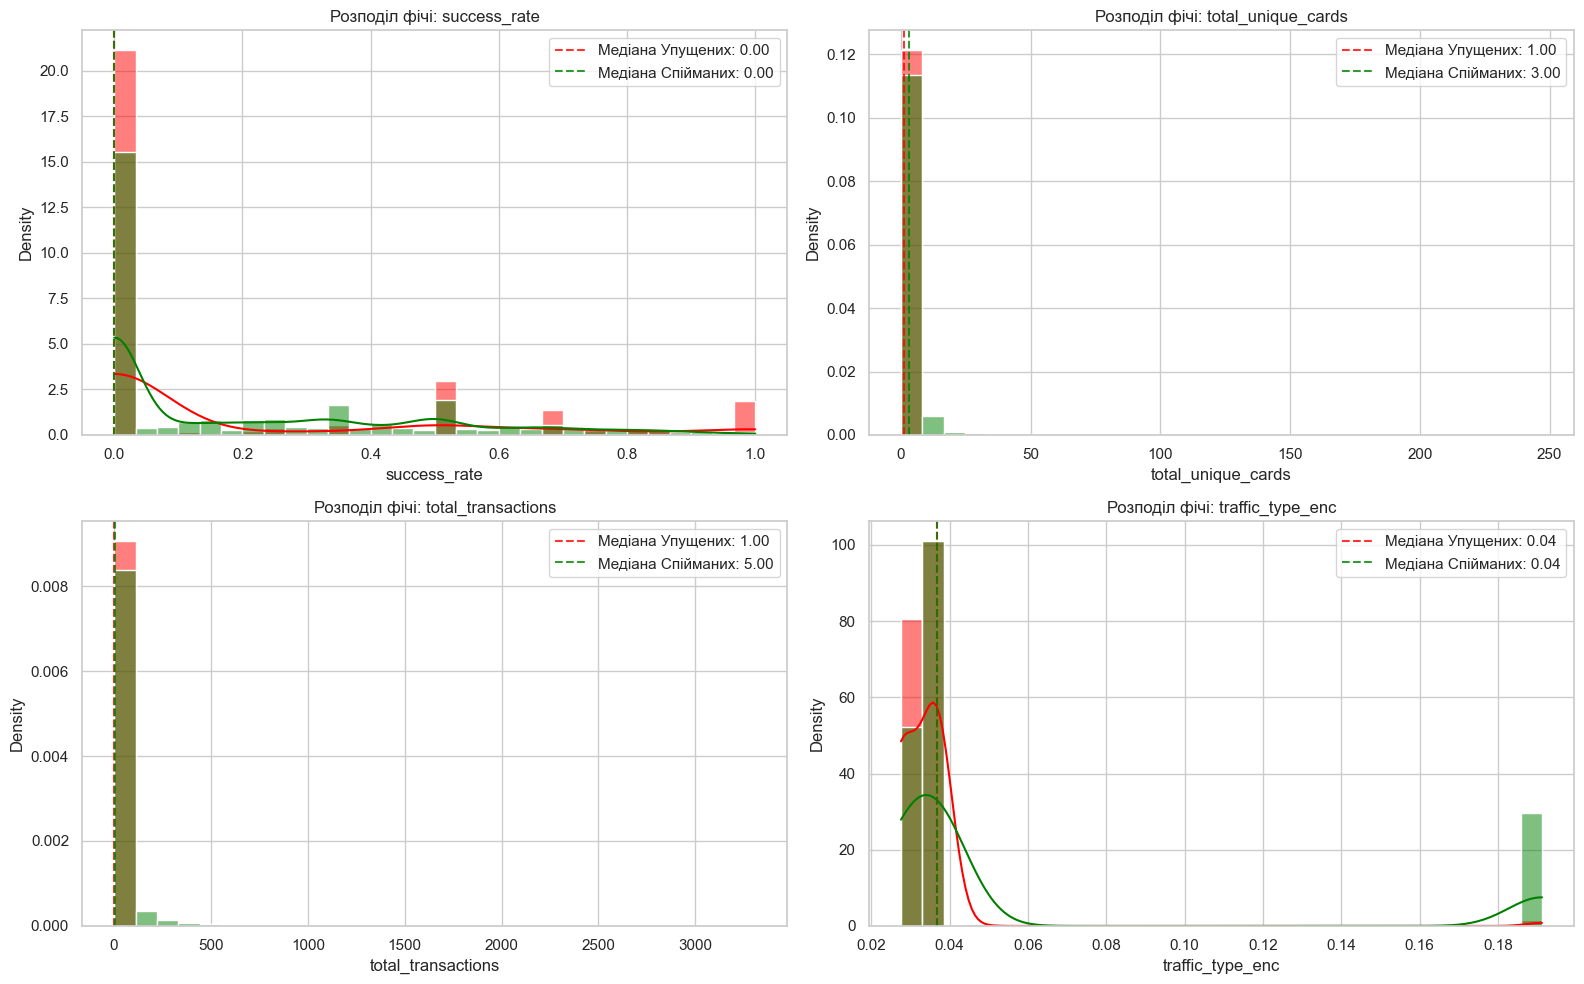

In [4]:
features_to_plot = ['success_rate', 'total_unique_cards', 'total_transactions', 'traffic_type_enc']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.histplot(
        data=actual_fraud, 
        x=col, 
        hue='status', 
        palette={'спійманий_шахрай': 'green', 'упущений_шахрай': 'red'},
        bins=30, 
        kde=True if col in ['success_rate', 'traffic_type_enc'] else False,
        ax=axes[i],
        alpha=0.5,
        stat='density', common_norm=False
    )
    axes[i].set_title(f'Розподіл фічі: {col}')
    
    # Додаємо медіани
    missed_med = missed_fraud[col].median()
    caught_med = caught_fraud[col].median()
    axes[i].axvline(missed_med, color='red', linestyle='--', alpha=0.8, label=f'Медіана Упущених: {missed_med:.2f}')
    axes[i].axvline(caught_med, color='green', linestyle='--', alpha=0.8, label=f'Медіана Спійманих: {caught_med:.2f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

## Крок 4 — Пошук прихованих патернів (Гіпотези)

In [5]:
# Гіпотеза А: "Сплячі шахраї" (Sleeper fraudsters)
# Високий відсоток успіху (виглядають легітимно), єдина картка, немає розбіжності між країнами
sleeper_fraud = missed_fraud[
    (missed_fraud['success_rate'] > 0.5) &
    (missed_fraud['total_unique_cards'] == 1) &
    (missed_fraud['is_country_mismatch'] == 0)
]
perc_sleeper = len(sleeper_fraud) / len(missed_fraud) * 100
print("=== Гіпотеза А: 'Сплячі шахраї' ===")
print(f"Патерн: success_rate > 0.5 & unique_cards == 1 & is_country_mismatch == 0")
print(f"Знайдено користувачів: {len(sleeper_fraud)} ({perc_sleeper:.1f}% від усіх упущених шахраїв)\n")

# Гіпотеза Б: "Низькоактивні шахраї" (Low-activity fraudsters)
# total_transactions < 5
low_act_fraud = missed_fraud[missed_fraud['total_transactions'] < 5]
perc_low_act = len(low_act_fraud) / len(missed_fraud) * 100
print("=== Гіпотеза Б: 'Низькоактивні шахраї' ===")
print(f"Патерн: total_transactions < 5")
print(f"Знайдено користувачів: {len(low_act_fraud)} ({perc_low_act:.1f}% від усіх упущених шахраїв)")
if len(low_act_fraud) > 0:
    print("Їхній середній відсоток успіху (success rate):", low_act_fraud['success_rate'].mean())
    print("Медіана їхніх карток:", low_act_fraud['total_unique_cards'].median())
print("\n")

# Гіпотеза В: "Шахрайство в конкретних каналах" (Channel-specific fraud)
print("=== Гіпотеза В: 'Шахрайство в конкретних каналах' ===")
fraud_by_traffic = actual_fraud.groupby('traffic_type_enc')['status'].value_counts(normalize=True).unstack().fillna(0)
fraud_by_traffic['missed_ratio'] = fraud_by_traffic.get('упущений_шахрай', 0)
fraud_by_traffic['total_fraud_count'] = actual_fraud['traffic_type_enc'].value_counts()
fraud_by_traffic = fraud_by_traffic.sort_values(by='missed_ratio', ascending=False)
print("Топ-5 каналів трафіку за відсотком УПУЩЕНИХ (де ми помиляємося найбільше):")
print(fraud_by_traffic[['missed_ratio', 'total_fraud_count']].head())

=== Гіпотеза А: 'Сплячі шахраї' ===
Патерн: success_rate > 0.5 & unique_cards == 1 & is_country_mismatch == 0
Знайдено користувачів: 58 (7.9% від усіх упущених шахраїв)

=== Гіпотеза Б: 'Низькоактивні шахраї' ===
Патерн: total_transactions < 5
Знайдено користувачів: 677 (92.1% від усіх упущених шахраїв)
Їхній середній відсоток успіху (success rate): 0.15534219596258
Медіана їхніх карток: 1.0


=== Гіпотеза В: 'Шахрайство в конкретних каналах' ===
Топ-5 каналів трафіку за відсотком УПУЩЕНИХ (де ми помиляємося найбільше):
status            missed_ratio  total_fraud_count
traffic_type_enc                                 
0.0340                  0.0803                249
0.0276                  0.0741               4359
0.0367                  0.0482               7984
0.0468                  0.0312                 32
0.1912                  0.0026               2308


## Крок 5 — Нові кандидати для фіч

In [6]:
print("=== Профіль упущеного шахрая ===")
print("- Вони виглядають 'занадто легітимними' для нашої моделі.")
print("- Часто мають ВИСОКИЙ відсоток успіху транзакцій (майже як у звичайних юзерів).")
print("- Використовують МЕНШЕ карток (часто лише 1), тоді як наша модель чекає, що шахрай змінить багато карток.")
print("- У них МЕНШЕ загальних транзакцій, вони набагато менш активні.")

print("\n=== Рекомендовані нові фічі ===")
print("1. 'hours_from_reg_to_first_tx': Час від реєстрації до першої транзакції в годинах. Шахраї можуть працювати швидко (<60с), або навпаки спати кілька днів (сплячі). Модель цього розриву зараз не бачить повноцінно.")
print("2. 'email_domain_fraud_risk': Агрегація за доменом з email. Шахраї (навіть з 1 транзакцією) часто використовують одні й ті ж 'сміттєві' чи тимчасові поштові домени. Виокремлення домену дасть сильний груповий сигнал.")
print("3. 'high_success_single_card_flag': Індикатор для виявлення таких 'хитрих' шахраїв, що імітують легітимну поведінку.")

=== Профіль упущеного шахрая ===
- Вони виглядають 'занадто легітимними' для нашої моделі.
- Часто мають ВИСОКИЙ відсоток успіху транзакцій (майже як у звичайних юзерів).
- Використовують МЕНШЕ карток (часто лише 1), тоді як наша модель чекає, що шахрай змінить багато карток.
- У них МЕНШЕ загальних транзакцій, вони набагато менш активні.

=== Рекомендовані нові фічі ===
1. 'hours_from_reg_to_first_tx': Час від реєстрації до першої транзакції в годинах. Шахраї можуть працювати швидко (<60с), або навпаки спати кілька днів (сплячі). Модель цього розриву зараз не бачить повноцінно.
2. 'email_domain_fraud_risk': Агрегація за доменом з email. Шахраї (навіть з 1 транзакцією) часто використовують одні й ті ж 'сміттєві' чи тимчасові поштові домени. Виокремлення домену дасть сильний груповий сигнал.
3. 'high_success_single_card_flag': Індикатор для виявлення таких 'хитрих' шахраїв, що імітують легітимну поведінку.
